In [1]:
import os
from os import path

args = {}
args["project_root"] = path.abspath(path.join(os.path.abspath(""), ".."))
args["captures_dir"] = path.join(args["project_root"], "dataset", "captures")

In [2]:
from video_utils import vid_cam

vid_cam.capture_image_from_stream(0, imgdir=args["captures_dir"])

In [3]:
from PIL import Image


def generate_captured_images(cap_img_dir):
    cap_img_names = os.listdir(cap_img_dir)
    
    for cap_img_name in cap_img_names:
        captured_img = Image.open(path.join(cap_img_dir, cap_img_name))

        yield captured_img

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def convert_to_grayscale(color_img):
    return cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)


def detect_edges(gray_img, min_threshold, max_threshold, aperture_size=5):
    return cv2.Canny(gray_img, min_threshold, max_threshold, aperture_size)


def perform_binary_thresholding(gray_img, threshold, maxval):
    ret, bin_img = cv2.threshold(
        gray_img, threshold, maxval, cv2.THRESH_BINARY)

    return bin_img


def detect_lines(col_img, bin_img, e_rho, e_theta, threshold):
    lines = cv2.HoughLines(bin_img, e_rho, e_theta, threshold)

    if lines is None:
        lines = []

    for line in lines:
        for rho, theta in line:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(col_img, (x1, y1), (x2, y2), (0, 255, 0), 2)


def detect_contours(col_img, bin_img, mode=cv2.RETR_TREE,
                    method=cv2.CHAIN_APPROX_SIMPLE):

    contours, hierarchy = cv2.findContours(
        image=bin_img, mode=mode, method=method)

    # draw contours on original image
    cv2.drawContours(image=col_img, contours=contours, contourIdx=-1,
                     color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)

    return contours, hierarchy


def get_id_card_contours(color_img, binary_thresholding=True,
                         edge_detection=True, edge_min_thresh=400,
                         edge_max_thresh=600, edge_aperture=5,
                         bin_thresh=125, bin_maxval=255,
                         cont_mode=cv2.RETR_TREE,
                         cont_method=cv2.CHAIN_APPROX_SIMPLE):

    pre_proc_img = convert_to_grayscale(color_img)

    if binary_thresholding:
        pre_proc_img = perform_binary_thresholding(
            pre_proc_img, bin_thresh, bin_maxval)

    if edge_detection:
        pre_proc_img = detect_edges(pre_proc_img, edge_min_thresh,
                                    edge_max_thresh, edge_aperture)

    return detect_contours(color_img, pre_proc_img, cont_mode, cont_method)


def draw_detected_id_card(color_img, binary_thresholding=False, contours=False,
                          edge_detection=True, line_detection=True,
                          edge_min_thresh=400, edge_max_thresh=600,
                          edge_aperture=5, bin_thresh=125, bin_maxval=255,
                          line_rho=1, line_theta=np.pi / 180, line_thresh=50,
                          cont_mode=cv2.RETR_TREE,
                          cont_method=cv2.CHAIN_APPROX_SIMPLE):

    fig, axes = plt.subplots(2, 3, figsize=(16, 12))

    pre_proc_img = convert_to_grayscale(color_img)
    axes[0, 0].set_title("Grayscale Image")
    axes[0, 0].axis("off")
    axes[0, 0].imshow(pre_proc_img)

    if binary_thresholding:
        pre_proc_img = perform_binary_thresholding(
            pre_proc_img, bin_thresh, bin_maxval)
        axes[0, 1].set_title("Binary Thresholded Image")
        axes[0, 1].axis("off")
        axes[0, 1].imshow(pre_proc_img)

    if edge_detection:
        pre_proc_img = detect_edges(pre_proc_img, edge_min_thresh,
                                    edge_max_thresh, edge_aperture)
        axes[0, 2].set_title("Edge Detected Image")
        axes[0, 2].axis("off")
        axes[0, 2].imshow(pre_proc_img)

    if contours:
        color_copy = color_img.copy()
        detect_contours(color_copy, pre_proc_img, cont_mode, cont_method)
        axes[1, 1].set_title("Countours Detected Image")
        axes[1, 1].axis("off")
        axes[1, 1].imshow(color_copy)

    if line_detection:
        color_copy = color_img.copy()
        detect_lines(color_copy, pre_proc_img,
                     line_rho, line_theta, line_thresh)
        axes[1, 0].set_title("Lines Detected Image")
        axes[1, 0].axis("off")
        axes[1, 0].imshow(color_copy)

    fig.show()

/home/workerap/.conda/envs/face-rec-fastapi/lib/python3.7/site-packages/ipykernel_launcher.py:117: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/home/workerap/.conda/envs/face-rec-fastapi/lib/python3.7/site-packages/ipykernel_launcher.py:81: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


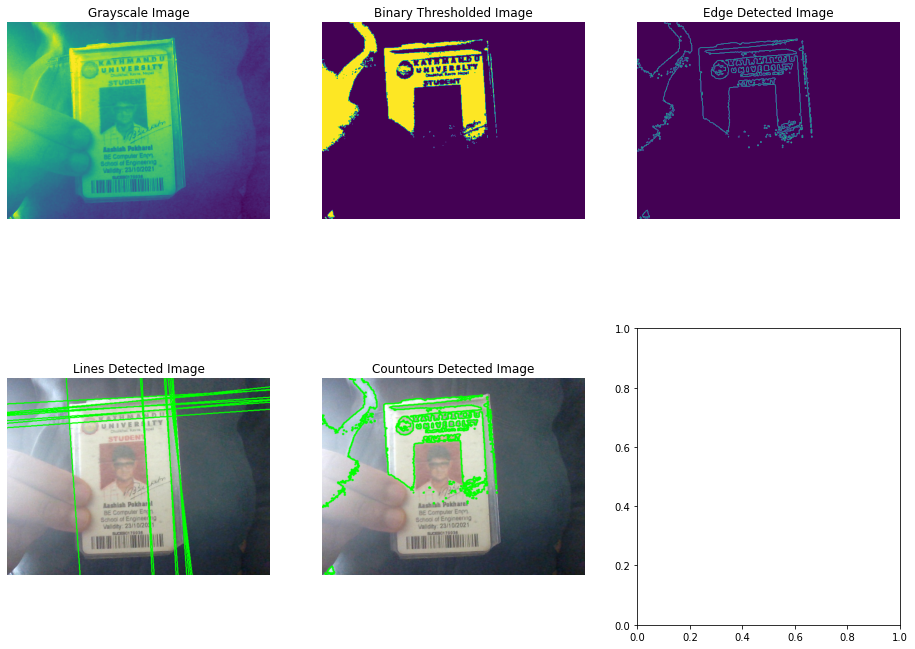

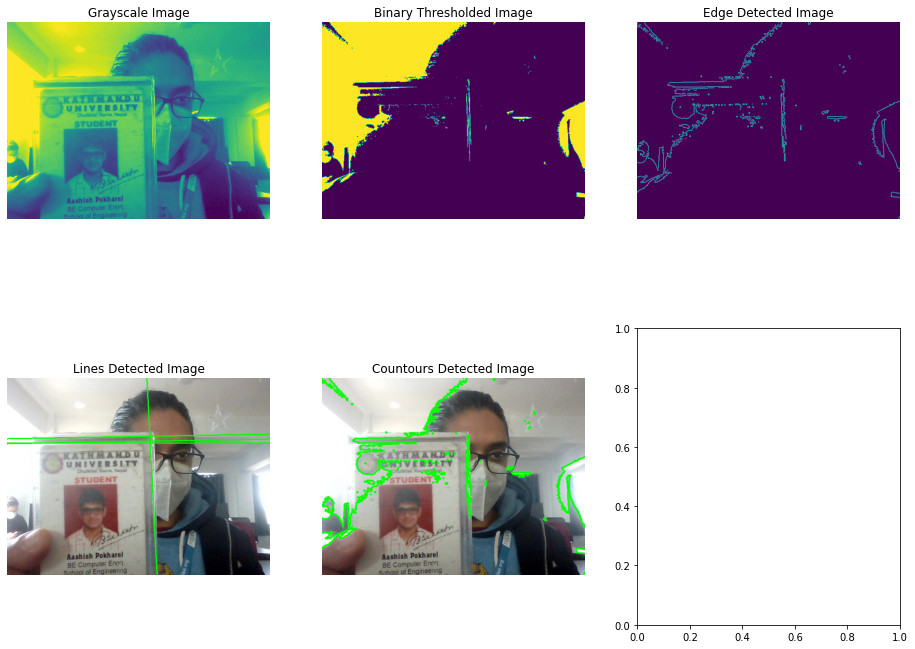

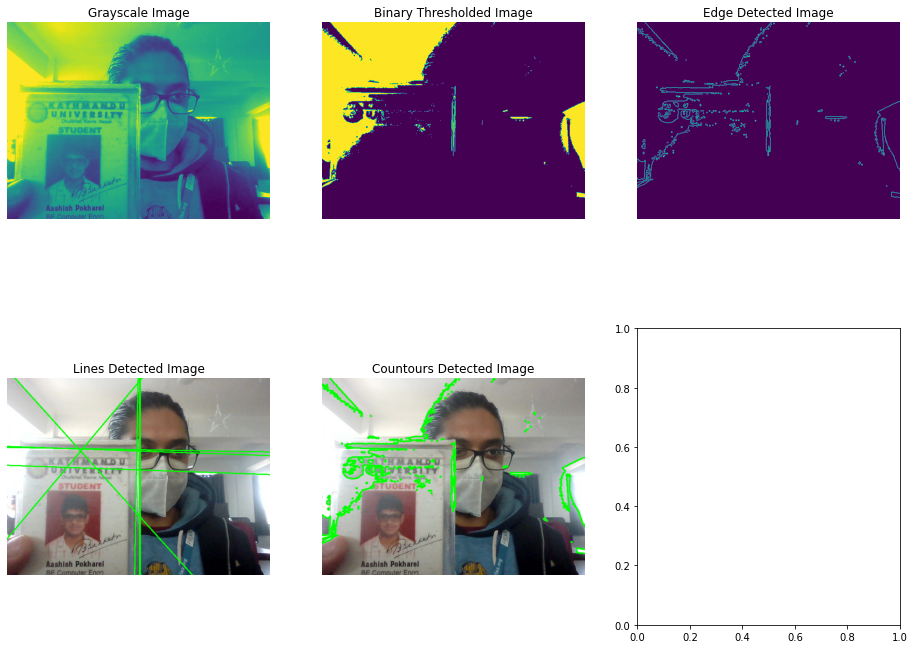

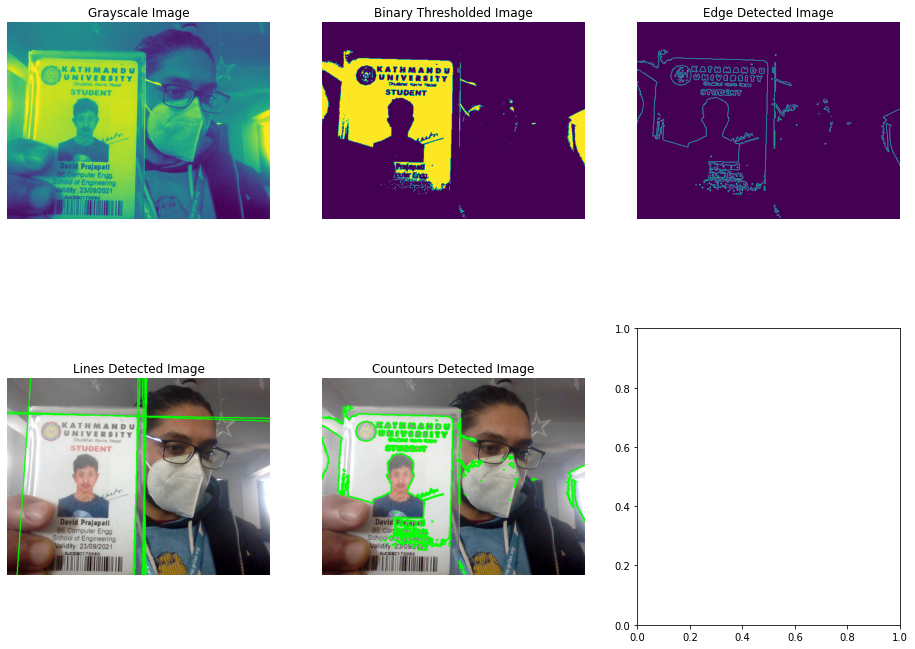

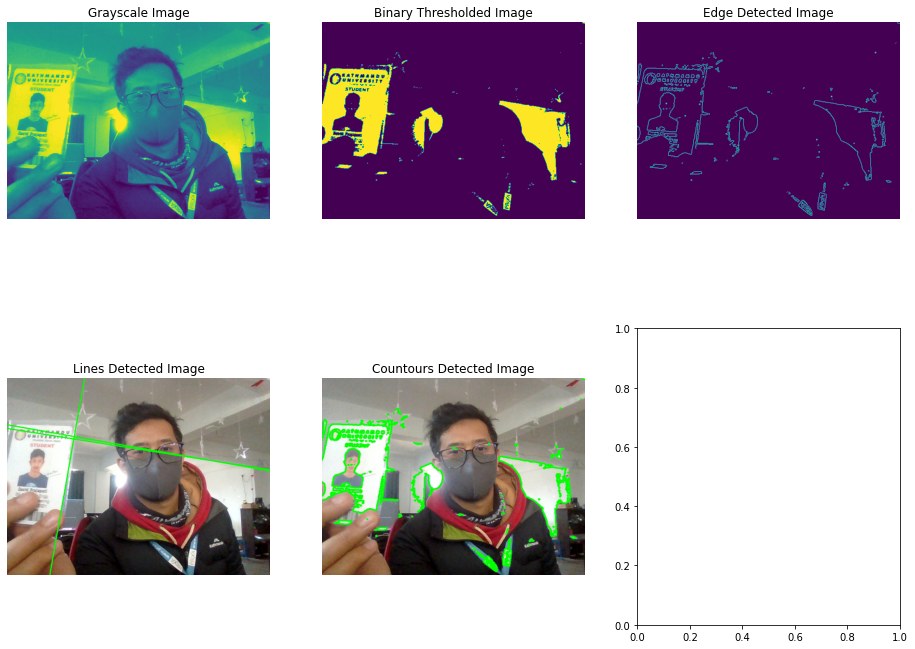

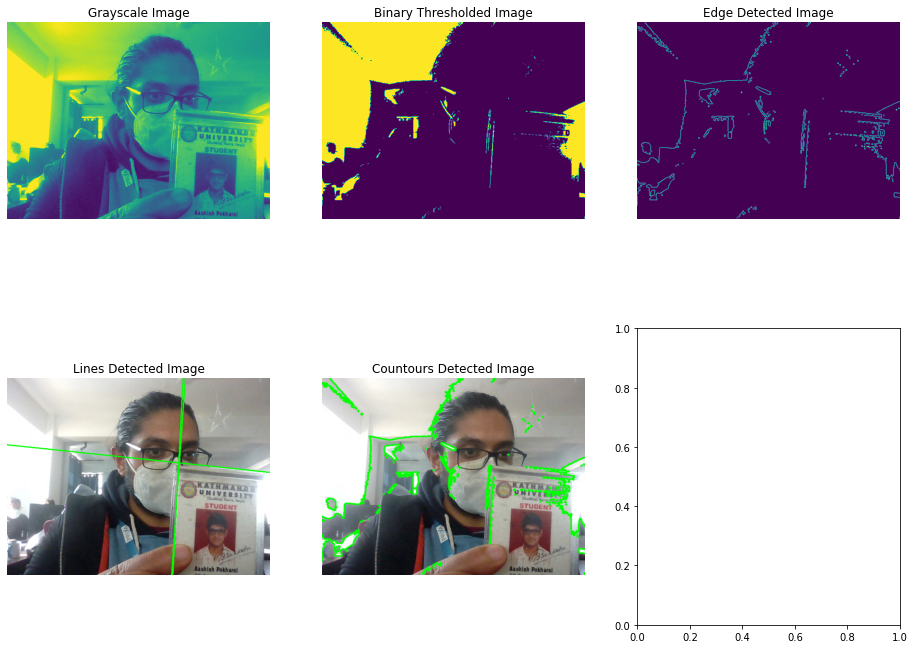

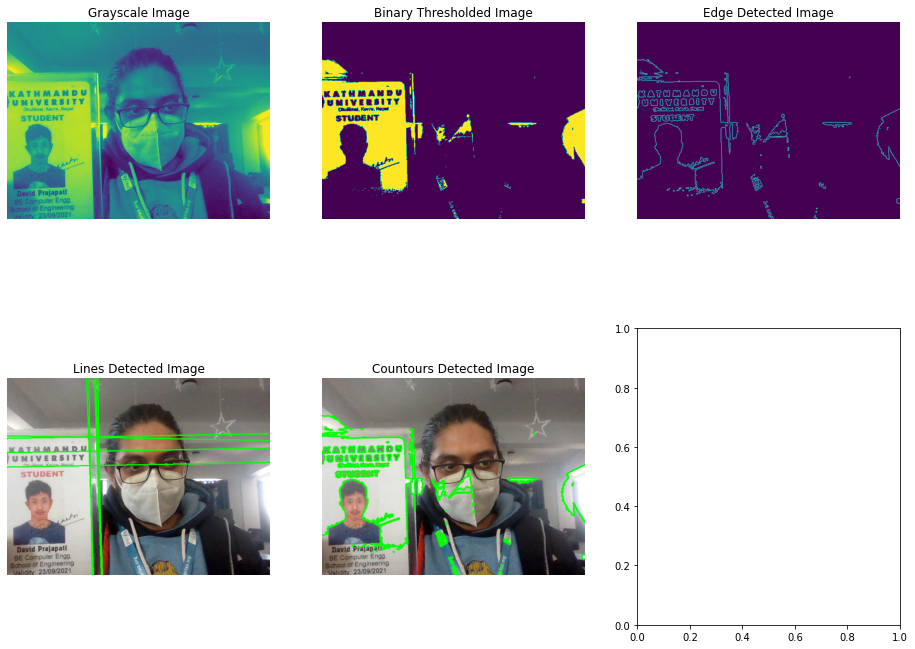

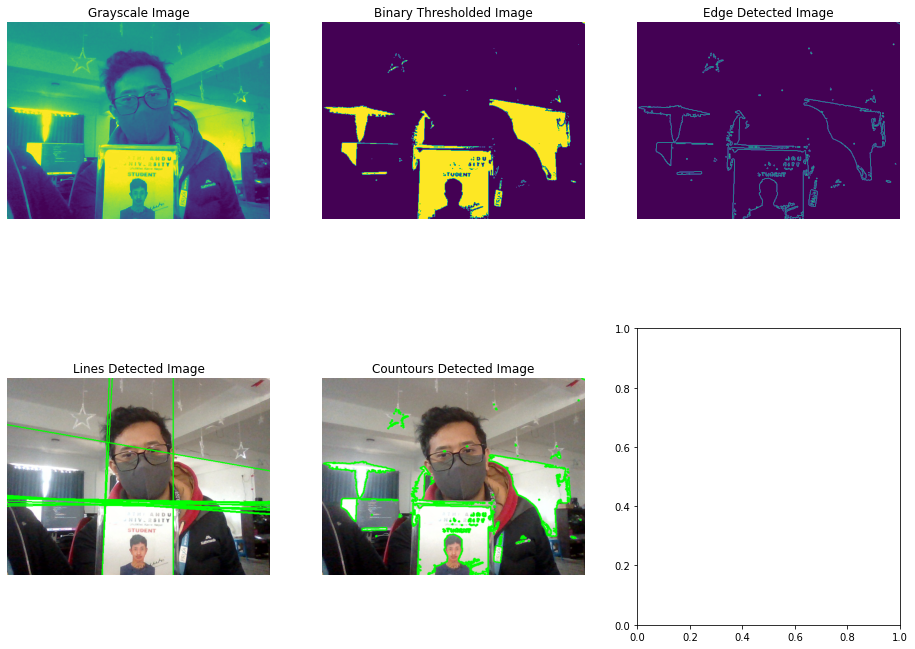

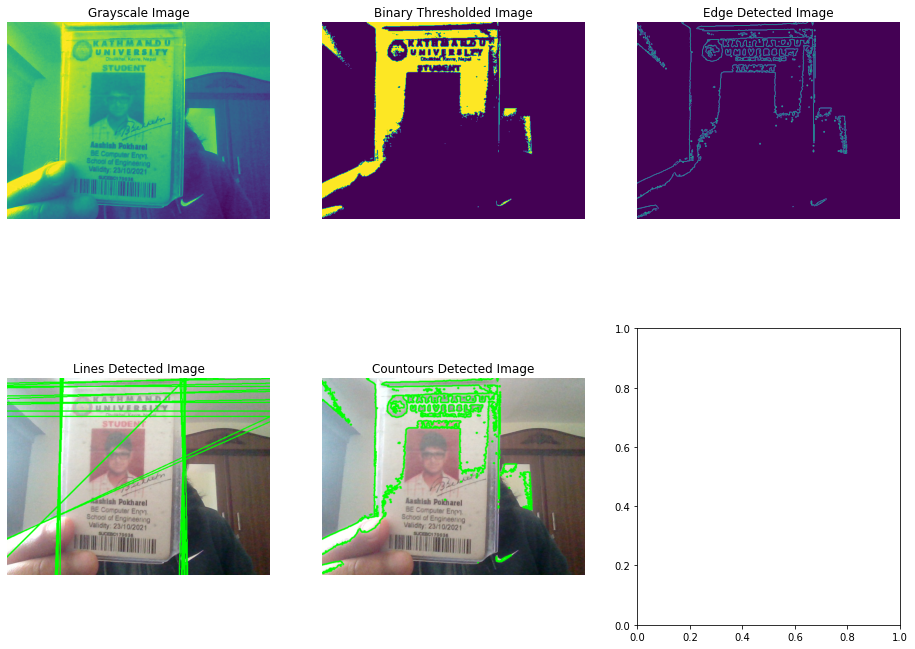

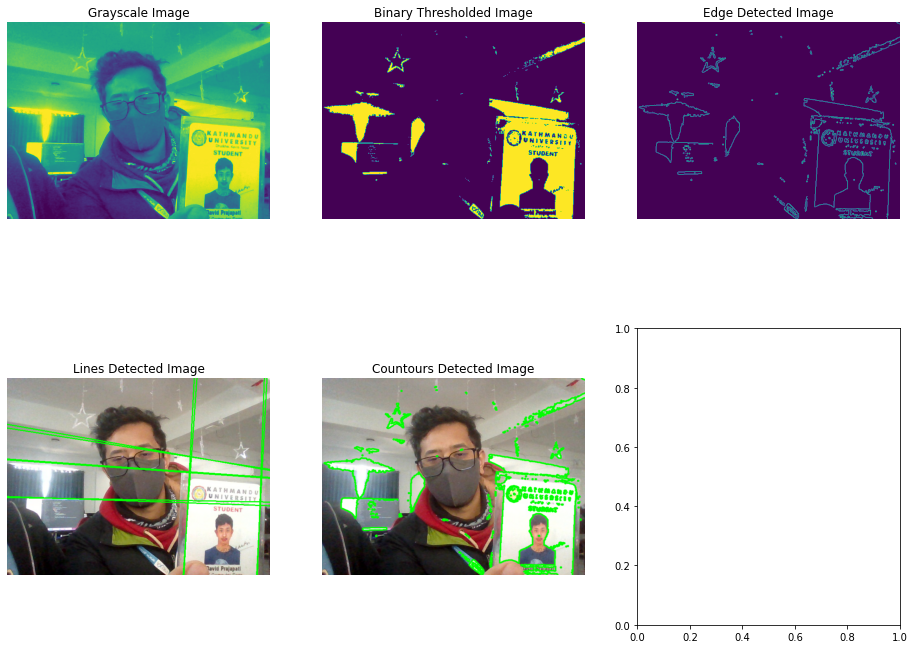

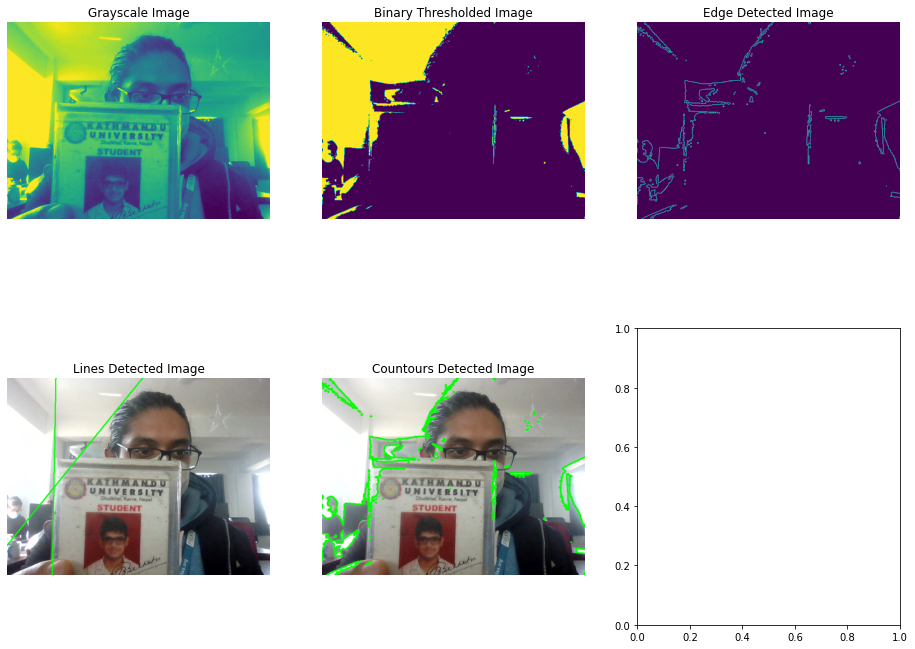

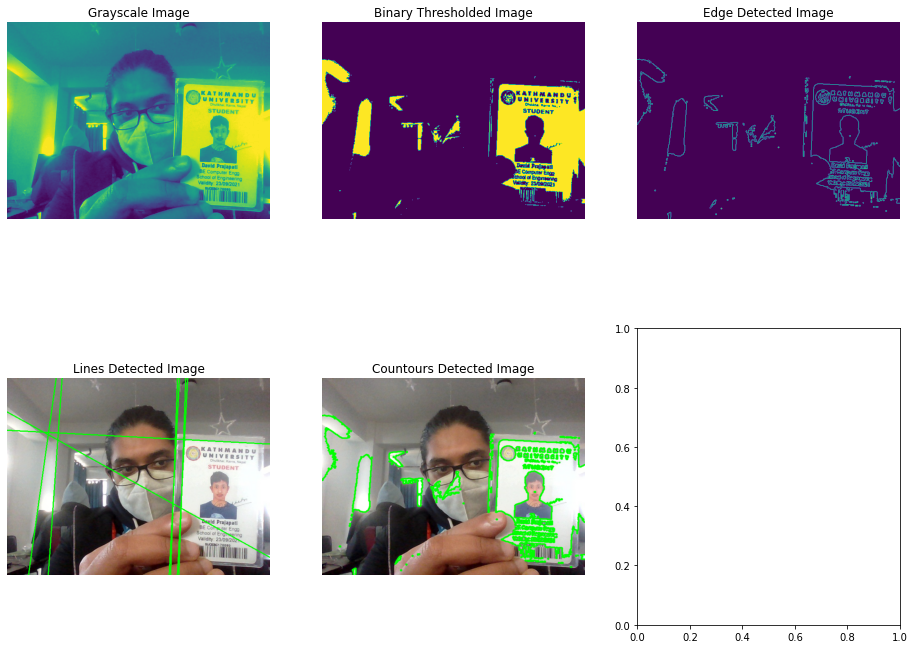

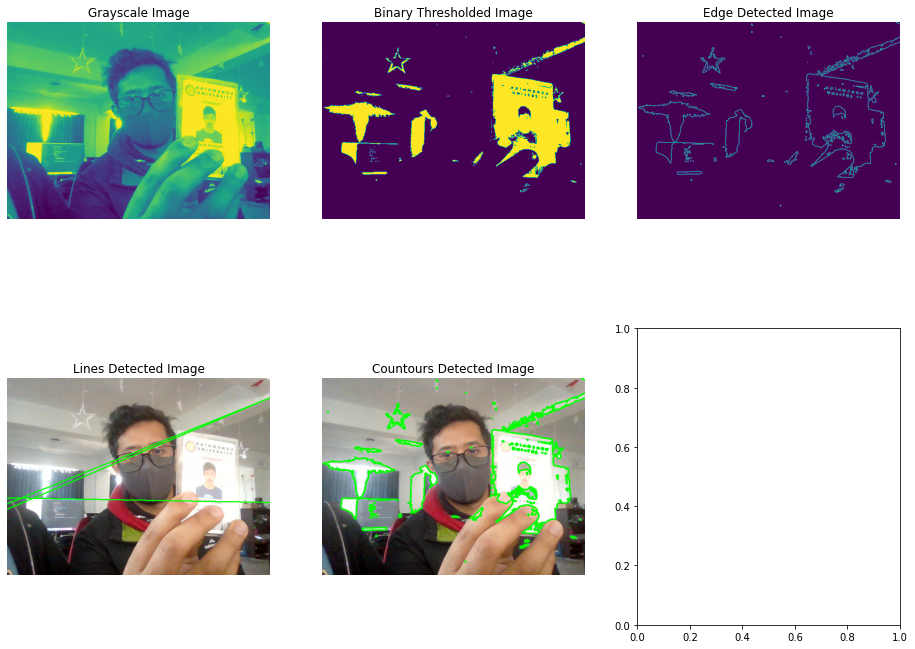

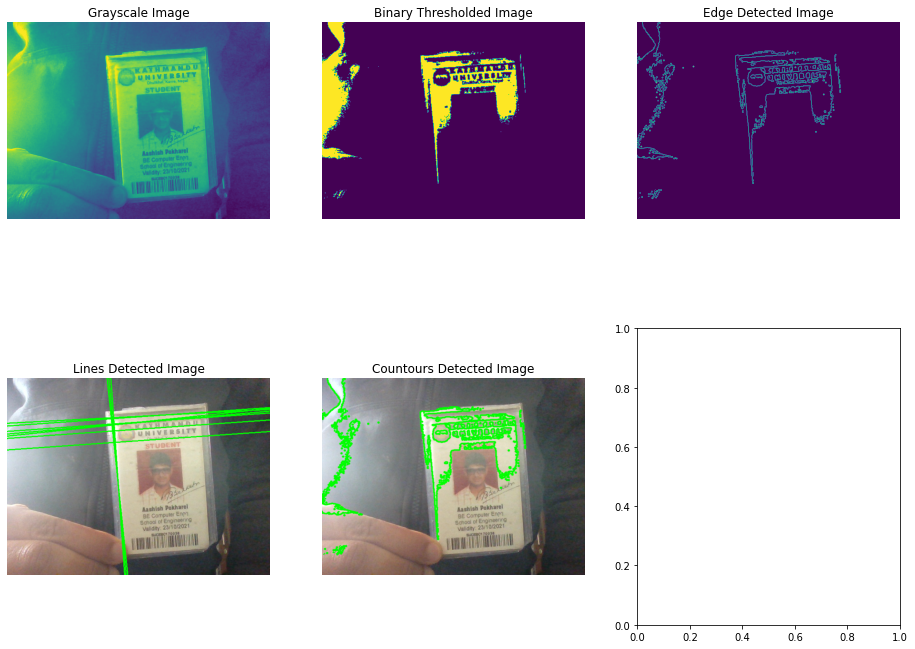

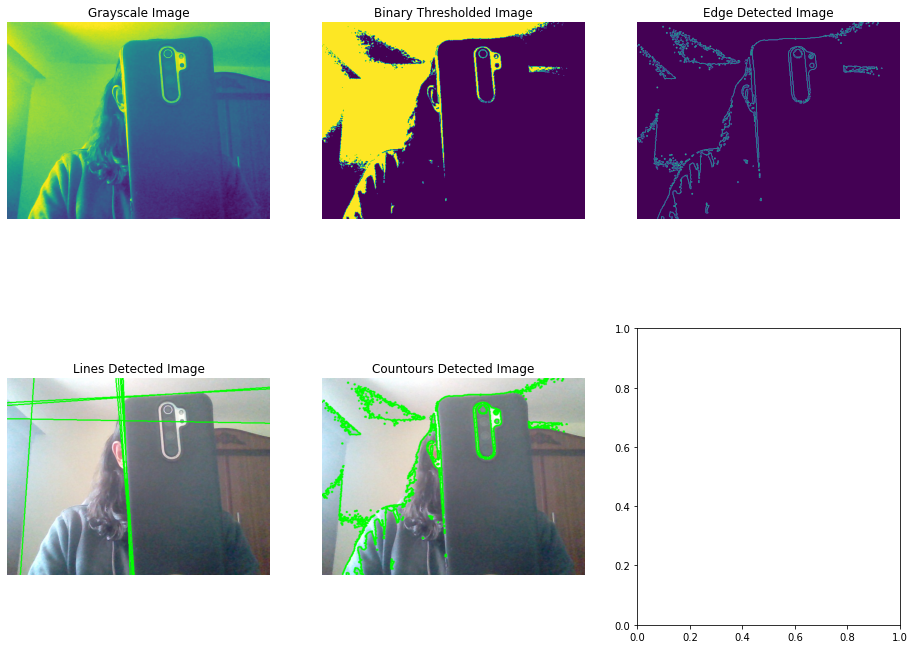

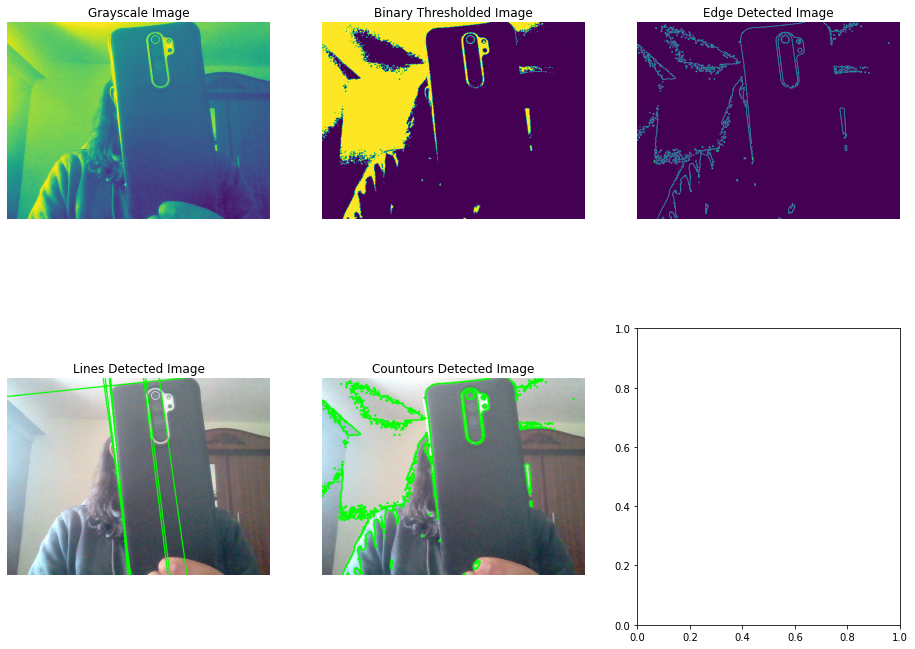

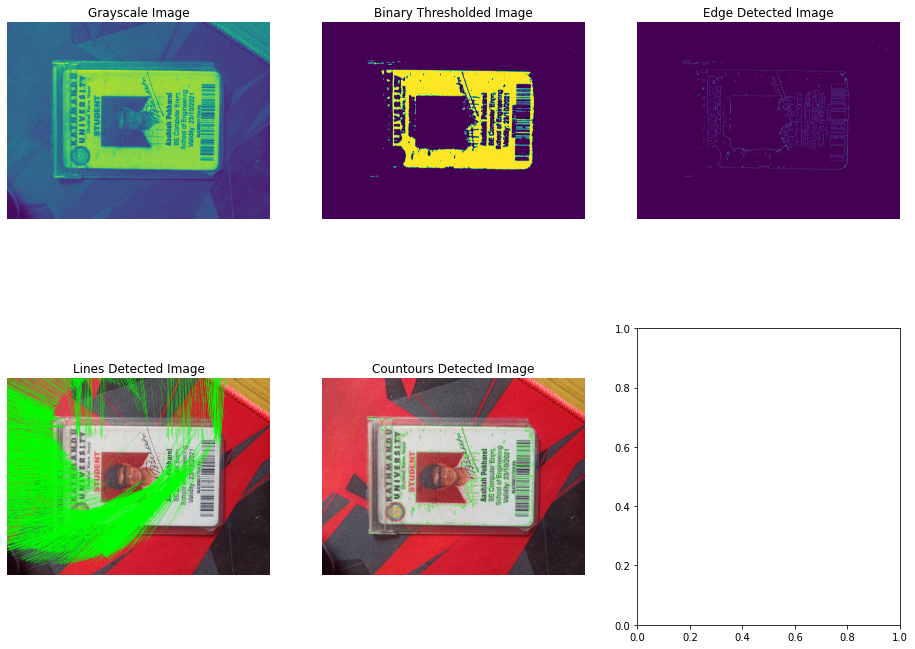

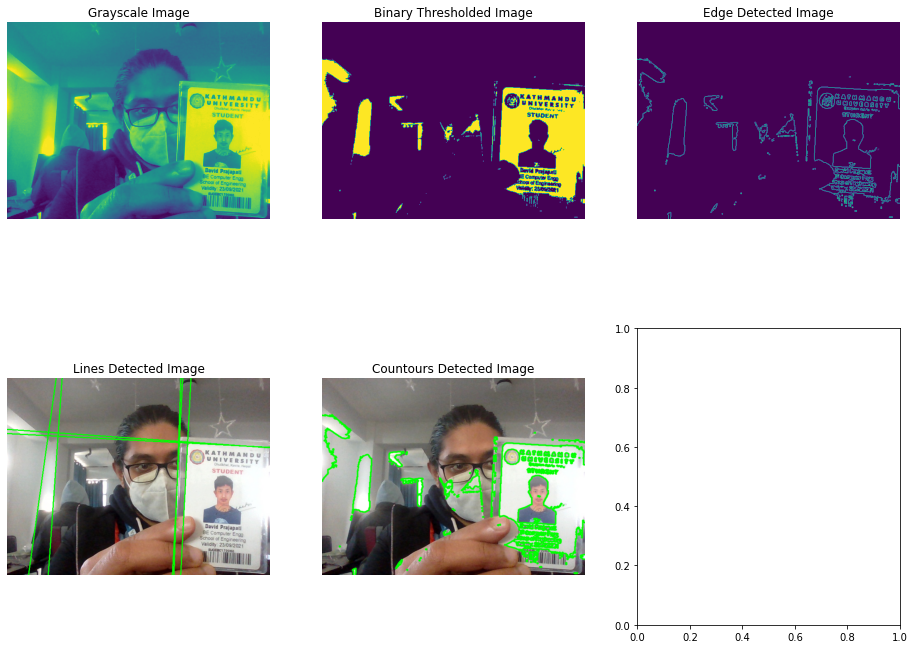

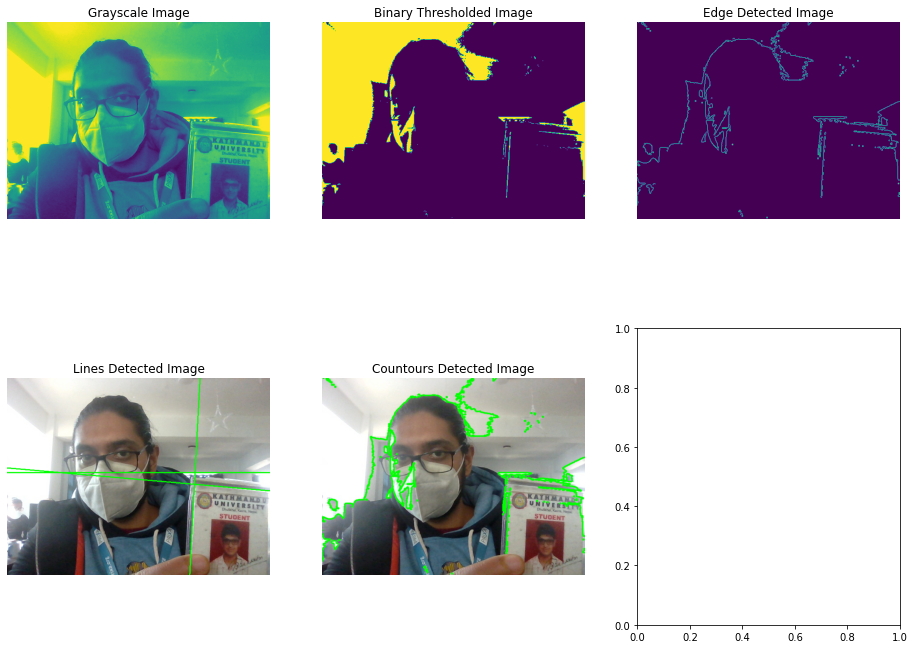

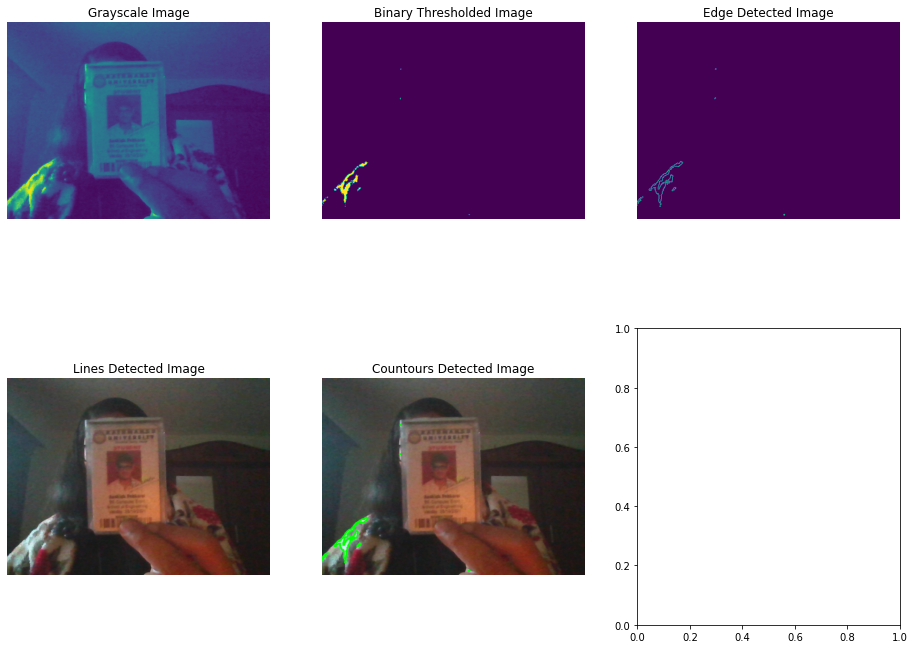

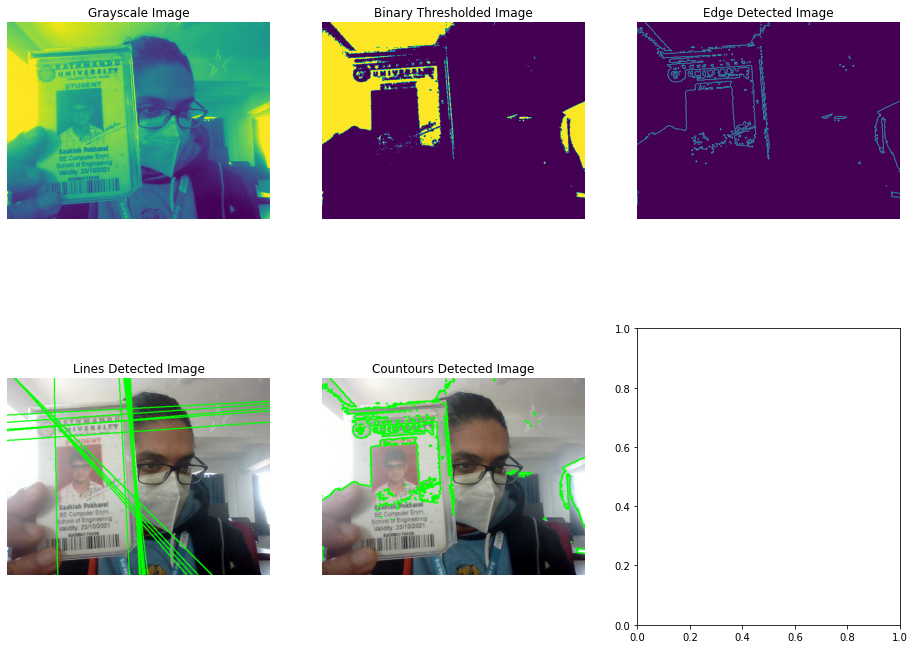

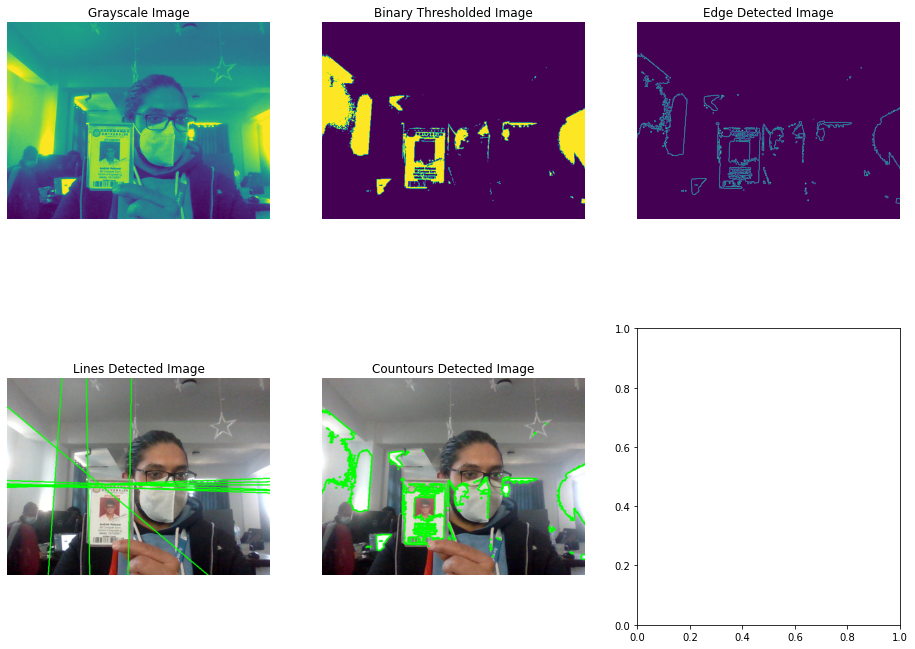

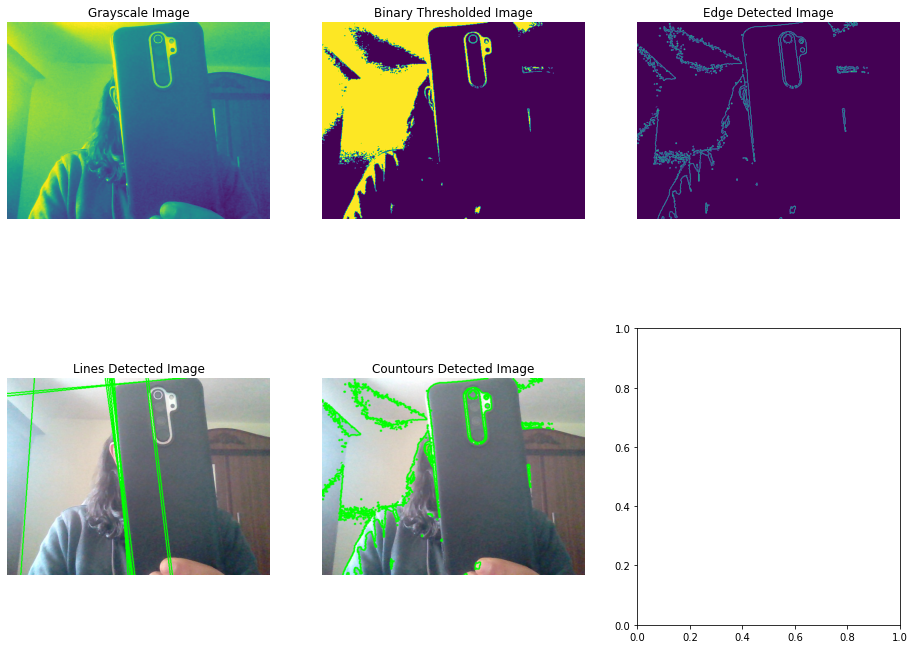

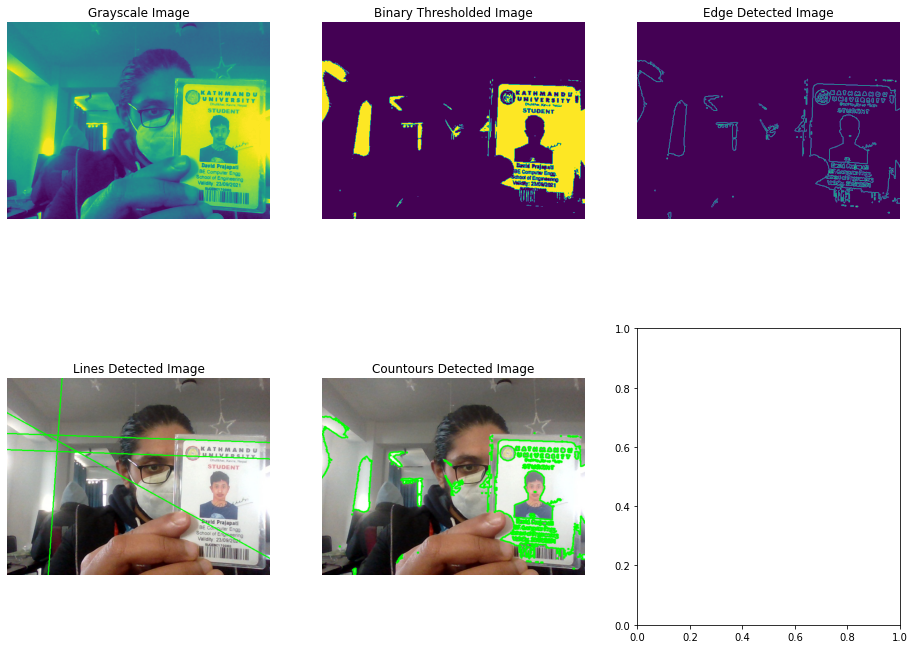

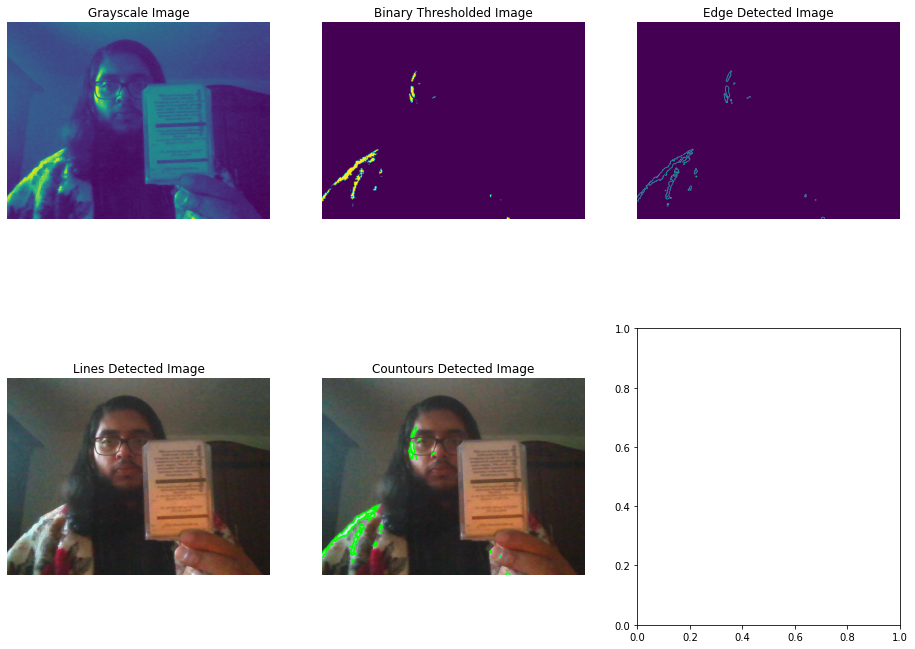

In [9]:
for t_img in generate_captured_images(args["captures_dir"]):
    draw_detected_id_card(np.array(t_img.copy()), edge_min_thresh=100,
                          edge_max_thresh=200, line_thresh=80, binary_thresholding=True,
                          contours=True, bin_thresh=200, bin_maxval=255,
                          cont_mode=cv2.RETR_EXTERNAL)

In [6]:
t_img = next(iter(generate_captured_images(args["captures_dir"])))

contours, hierarchy = get_id_card_contours(np.array(t_img.copy()), edge_min_thresh=100,
                                           edge_max_thresh=200,
                                           bin_thresh=200, bin_maxval=255)

In [7]:
# contours, hierarchy
hierarchy

array([[[  1,  -1,  -1,  -1],
        [  2,   0,  -1,  -1],
        [  3,   1,  -1,  -1],
        ...,
        [ -1,  -1,  -1, 388],
        [391, 388,  -1,  -1],
        [ -1, 390,  -1,  -1]]], dtype=int32)